In [2]:

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("ess_cleaned_data.csv")

# Replace ESS missing values
df = df.replace([77, 88, 99], np.nan)

# Construct Universalism index
df["universalism"] = df[["ipeqopt", "ipudrst", "iphlppl"]].mean(axis=1)

# Check basic output
df[["gincdif", "universalism"]].describe()

,gincdif,universalism
count,135189.000000,73725.000000
mean,2.120195,4.762815
std,1.002866,0.810573
min,1.000000,1.000000
25%,1.000000,4.333333
50%,2.000000,5.000000
75%,3.000000,5.333333
max,5.000000,6.000000



The dataset was loaded from the ESS (European Social Survey) cleaned data file. ESS-specific missing value codes (77, 88, 99) were replaced with NaN to ensure they are excluded from calculations.
Universalism Index
A composite Universalism index was constructed by averaging three ESS items:

ipeqopt — equal opportunities for all
ipudrst — understanding different people
iphlppl — helping people and caring for their wellbeing

These three items reflect the core Universalism value dimension as defined by Schwartz's theory of basic human values, where higher scores indicate stronger universalism values.

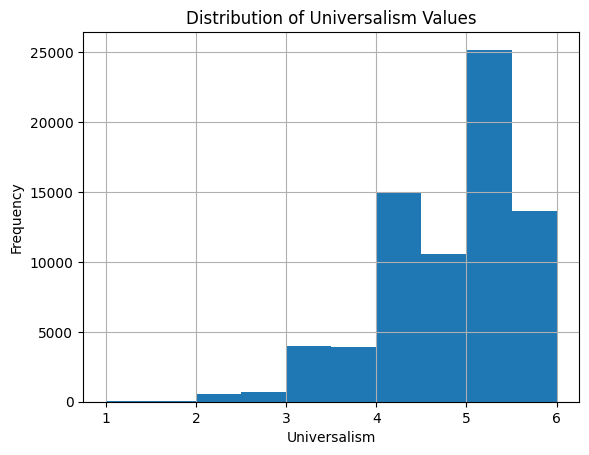

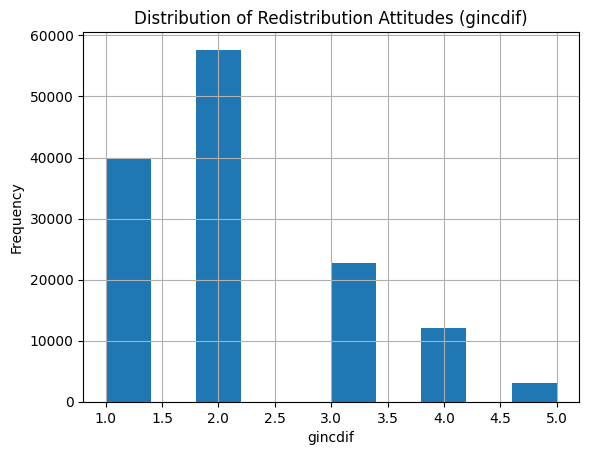

              universalism   gincdif
universalism      1.000000 -0.122289
gincdif          -0.122289  1.000000


In [3]:
import matplotlib.pyplot as plt

# Histogram of Universalism
plt.figure()
df["universalism"].hist()
plt.title("Distribution of Universalism Values")
plt.xlabel("Universalism")
plt.ylabel("Frequency")
plt.show()

# Histogram of redistribution attitudes
plt.figure()
df["gincdif"].hist()
plt.title("Distribution of Redistribution Attitudes (gincdif)")
plt.xlabel("gincdif")
plt.ylabel("Frequency")
plt.show()

# Correlation
corr = df[["universalism", "gincdif"]].corr()
print(corr)

In [4]:
def assign_generation(year):
    if pd.isna(year):
        return np.nan
    elif 1997 <= year <= 2012:
        return "Gen Z"
    elif 1981 <= year <= 1996:
        return "Millennials"
    elif 1965 <= year <= 1980:
        return "Gen X"
    elif 1946 <= year <= 1964:
        return "Boomers"
    else:
        return "Other"

df["generation"] = df["yrbrn"].apply(assign_generation)

# Mean redistribution by generation
group_means = df.groupby("generation")["gincdif"].mean()
print(group_means)

generation
Boomers        2.047128
Gen X          2.154616
Gen Z          2.249687
Millennials    2.167824
Other          2.031686
Name: gincdif, dtype: float64


Preliminary Findings

The exploratory analysis provides initial insight into the relationship between Universalism values and attitudes toward income redistribution.

The distribution of Universalism values indicates variation in the importance individuals place on equality and social justice. Similarly, responses to the redistribution variable (gincdif) show differing levels of support for government intervention in reducing income inequality.

Preliminary correlation analysis suggests a relationship between Universalism and redistribution attitudes, with individuals who score higher on Universalism tending to express stronger support for redistribution.

When comparing across generational cohorts, differences emerge in average attitudes toward redistribution. These initial patterns suggest that generational differences may play a role in shaping how values translate into political preferences.
